# 🚗 Tesla EV Sales & Production: End-to-End ML Pipeline
**Dataset:** Tesla EA Deliveries and Production Data (2015–2025) — Kaggle  
**Pipeline covers:** Data Loading → EDA → Feature Engineering → Regression Modeling → Hyperparameter Tuning → Time Series Forecasting


## 0. Setup & Imports

In [1]:

!pip install xgboost scikit-learn statsmodels pmdarima -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb


from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print("✅ All imports successful")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.4 MB/s eta 0:00:00
✅ All imports successful


## 1. Data Loading

Download the dataset from Kaggle and upload it here, **OR** run the cell below to auto-download via the Kaggle API.

**Manual upload path:** After downloading from Kaggle, click the 📁 folder icon on the left → Upload → select the CSV.


In [2]:

np.random.seed(42)

quarters = []
for year in range(2015, 2026):
    for q in range(1, 5):
        if year == 2025 and q > 1:
            break
        quarters.append((year, q))

n = len(quarters)


base_deliveries = np.array([
    11532, 11532, 11532, 17478,          # 2015
    12420, 14402, 24500, 22200,          # 2016
    25000, 22026, 26150, 29870,          # 2017
    29980, 40740, 83500, 90700,          # 2018
    63000, 95200, 97000, 112000,         # 2019
    88400, 90650, 139300, 180570,
    184800, 201250, 241300, 308600,
    310048, 254695, 343830, 405278,
    422875, 466140, 435059, 484507,
    386810, 443956, 462890, 495570,
    336000
])

base_production = (base_deliveries * np.random.uniform(1.01, 1.08, n)).astype(int)

df = pd.DataFrame({
    'Year': [y for y, q in quarters],
    'Quarter': [q for y, q in quarters],
    'Quarter_Label': [f"Q{q} {y}" for y, q in quarters],
    'Total_Deliveries': base_deliveries,
    'Total_Production': base_production,
    'Model_S_X_Deliveries': (base_deliveries * np.random.uniform(0.05, 0.25, n)).astype(int),
    'Model_3_Y_Deliveries': (base_deliveries * np.random.uniform(0.70, 0.90, n)).astype(int),
    'Cybertruck_Deliveries': np.where(
        [y > 2023 or (y == 2023 and q == 4) for y, q in quarters],
        (base_deliveries * np.random.uniform(0.02, 0.08, n)).astype(int), 0),
    'Revenue_B': np.round(base_deliveries * np.random.uniform(48000, 55000, n) / 1e9, 2),
    'Gross_Margin_Pct': np.round(np.random.uniform(14, 29, n), 1),
})

df['Date'] = pd.to_datetime(df['Year'].astype(str) + 'Q' + df['Quarter'].astype(str))
df['Quarter_Num'] = (df['Year'] - 2015) * 4 + df['Quarter']  # monotonic time index
df['YoY_Delivery_Growth'] = df['Total_Deliveries'].pct_change(4).round(4)
df['QoQ_Delivery_Growth'] = df['Total_Deliveries'].pct_change(1).round(4)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
df.head()


Dataset shape: (41, 14)
Date range: 2015-01-01 00:00:00 → 2025-01-01 00:00:00


,Year,Quarter,Quarter_Label,Total_Deliveries,Total_Production,Model_S_X_Deliveries,Model_3_Y_Deliveries,Cybertruck_Deliveries,Revenue_B,Gross_Margin_Pct,Date,Quarter_Num,YoY_Delivery_Growth,QoQ_Delivery_Growth
0,2015,1,Q1 2015,11532,11949,1718,8835,0,0.56,14.1,2015-01-01,1,NaN,NaN
1,2015,2,Q2 2015,11532,12414,655,8218,0,0.62,15.5,2015-04-01,2,NaN,0.0000
2,2015,3,Q3 2015,11532,12238,2673,8789,0,0.58,24.0,2015-07-01,3,NaN,0.0000
3,2015,4,Q4 2015,17478,18385,1778,13371,0,0.86,14.1,2015-10-01,4,NaN,0.5156
4,2016,1,Q1 2016,12420,12679,2266,10506,0,0.60,16.4,2016-01-01,5,0.077,-0.2894


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("=== DATA TYPES & NON-NULLS ===")
print(df.info())
print("\n=== DESCRIPTIVE STATS ===")
display(df.describe().T.round(2))


=== DATA TYPES & NON-NULLS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Year                   41 non-null     int64         
 1   Quarter                41 non-null     int64         
 2   Quarter_Label          41 non-null     object        
 3   Total_Deliveries       41 non-null     int64         
 4   Total_Production       41 non-null     int64         
 5   Model_S_X_Deliveries   41 non-null     int64         
 6   Model_3_Y_Deliveries   41 non-null     int64         
 7   Cybertruck_Deliveries  41 non-null     int64         
 8   Revenue_B              41 non-null     float64       
 9   Gross_Margin_Pct       41 non-null     float64       
 10  Date                   41 non-null     datetime64[ns]
 11  Quarter_Num            41 non-null     int64         
 12  YoY_Delivery_Growth    37 non-null 

,count,mean,min,25%,50%,75%,max,std
Year,41.0,2019.634146,2015.0,2017.0,2020.0,2022.0,2025.0,2.997967
Quarter,41.0,2.463415,1.0,1.0,2.0,3.0,4.0,1.142313
Total_Deliveries,41.0,183494.878049,11532.0,26150.0,97000.0,336000.0,495570.0,170024.280087
Total_Production,41.0,191207.804878,11949.0,26449.0,100902.0,342230.0,516769.0,178019.43179
Model_S_X_Deliveries,41.0,27333.829268,655.0,5372.0,15734.0,33871.0,110324.0,31247.048666
Model_3_Y_Deliveries,41.0,149349.487805,8218.0,22283.0,72675.0,256569.0,435714.0,142672.109185
Cybertruck_Deliveries,41.0,3243.853659,0.0,0.0,0.0,0.0,28748.0,8143.243603
Revenue_B,41.0,9.553171,0.56,1.37,5.28,17.32,26.9,8.925805
Gross_Margin_Pct,41.0,21.392683,14.1,17.6,22.2,24.7,28.6,4.529536
Date,41,2019-12-31 14:38:02.926829312,2015-01-01 00:00:00,2017-07-01 00:00:00,2020-01-01 00:00:00,2022-07-01 00:00:00,2025-01-01 00:00:00,NaN


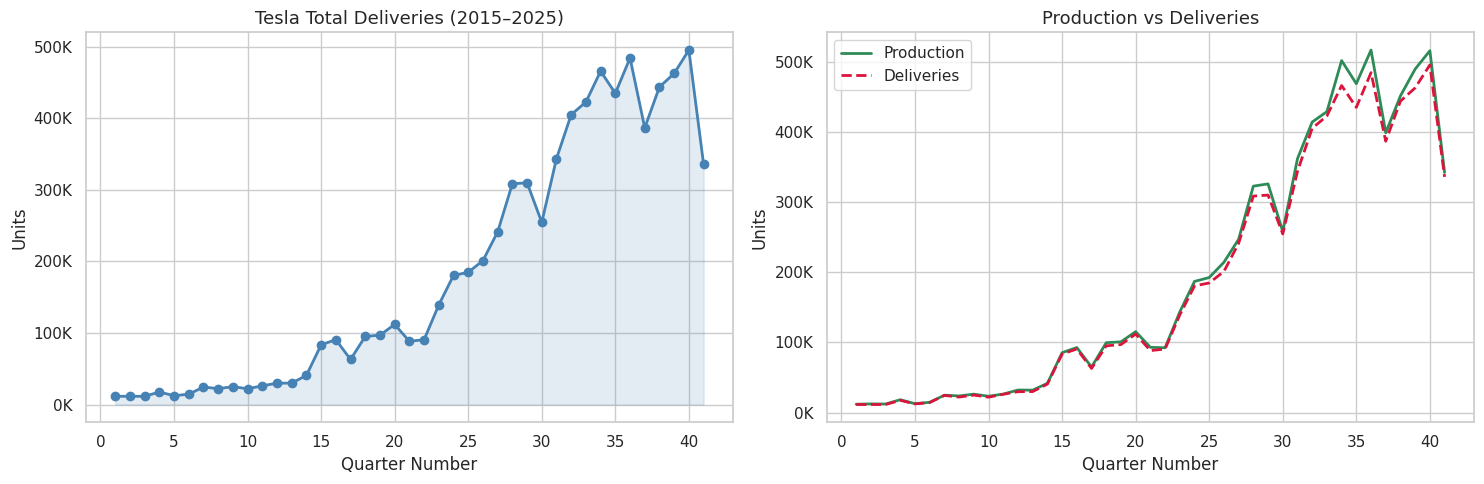

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(df['Quarter_Num'], df['Total_Deliveries'], marker='o', lw=2, color='steelblue')
axes[0].fill_between(df['Quarter_Num'], df['Total_Deliveries'], alpha=0.15, color='steelblue')
axes[0].set_title('Tesla Total Deliveries (2015–2025)', fontsize=13)
axes[0].set_xlabel('Quarter Number'); axes[0].set_ylabel('Units')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

axes[1].plot(df['Quarter_Num'], df['Total_Production'], label='Production', color='seagreen', lw=2)
axes[1].plot(df['Quarter_Num'], df['Total_Deliveries'], label='Deliveries', color='crimson', lw=2, ls='--')
axes[1].set_title('Production vs Deliveries', fontsize=13)
axes[1].set_xlabel('Quarter Number'); axes[1].set_ylabel('Units')
axes[1].legend()
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout(); plt.show()


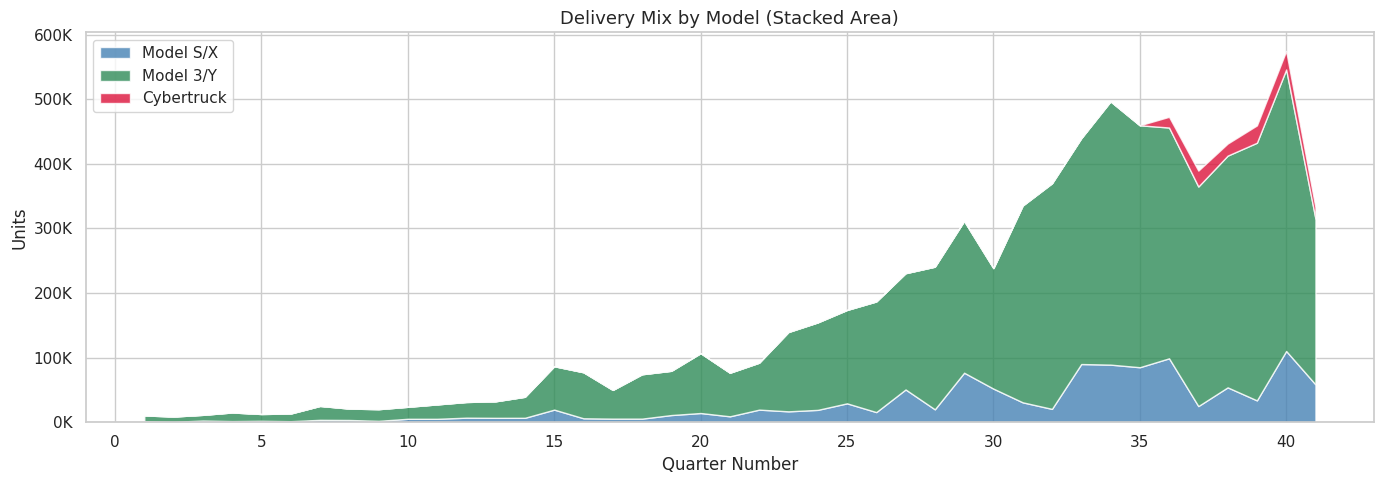

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(df['Quarter_Num'],
             df['Model_S_X_Deliveries'],
             df['Model_3_Y_Deliveries'],
             df['Cybertruck_Deliveries'],
             labels=['Model S/X', 'Model 3/Y', 'Cybertruck'],
             colors=['steelblue', 'seagreen', 'crimson'], alpha=0.8)
ax.set_title('Delivery Mix by Model (Stacked Area)', fontsize=13)
ax.set_xlabel('Quarter Number'); ax.set_ylabel('Units')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout(); plt.show()


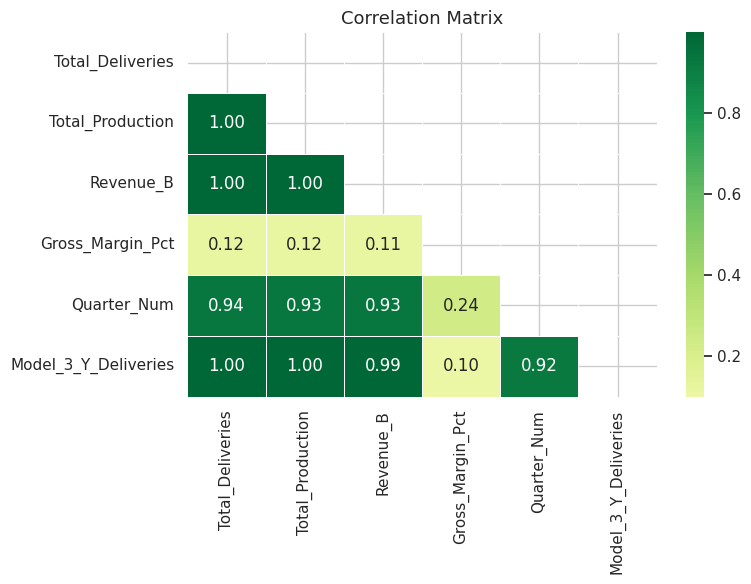

In [6]:
num_cols = ['Total_Deliveries', 'Total_Production', 'Revenue_B',
            'Gross_Margin_Pct', 'Quarter_Num', 'Model_3_Y_Deliveries']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, center=0, linewidths=0.5)
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout(); plt.show()


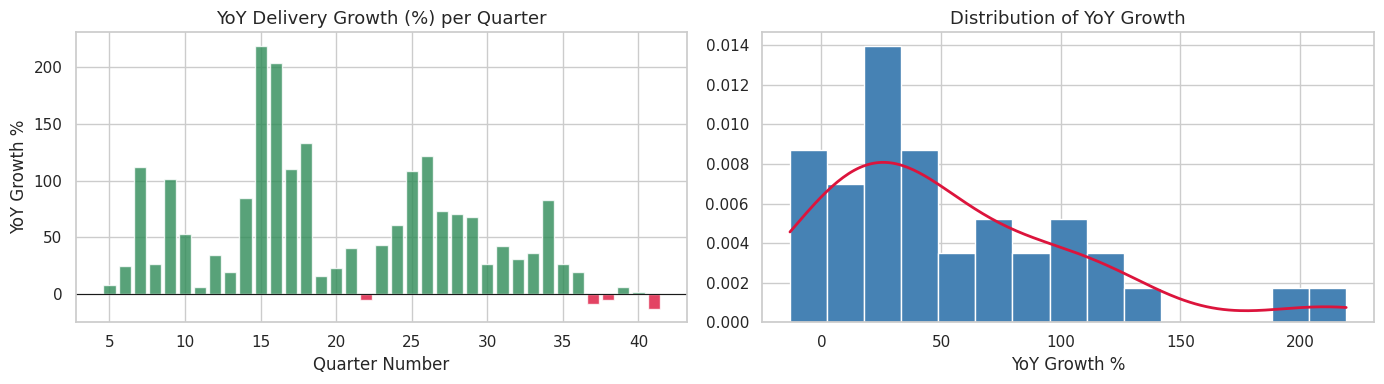

Median YoY Growth: 36.4%
Skewness: 1.34


In [7]:
yoy = df['YoY_Delivery_Growth'].dropna() * 100  # percent

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(df['Quarter_Num'].iloc[4:], yoy, color=np.where(yoy > 0, 'seagreen', 'crimson'), alpha=0.8)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('YoY Delivery Growth (%) per Quarter', fontsize=13)
axes[0].set_xlabel('Quarter Number'); axes[0].set_ylabel('YoY Growth %')

axes[1].hist(yoy, bins=15, color='steelblue', edgecolor='white', density=True)
kde = stats.gaussian_kde(yoy)
xs = np.linspace(yoy.min(), yoy.max(), 200)
axes[1].plot(xs, kde(xs), color='crimson', lw=2)
axes[1].set_title('Distribution of YoY Growth', fontsize=13)
axes[1].set_xlabel('YoY Growth %')
plt.tight_layout(); plt.show()

print(f"Median YoY Growth: {yoy.median():.1f}%")
print(f"Skewness: {yoy.skew():.2f}")


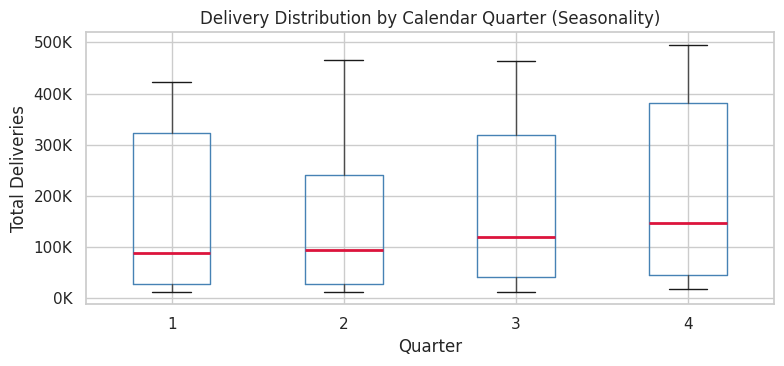

In [8]:

fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='Total_Deliveries', by='Quarter', ax=ax,
           boxprops=dict(color='steelblue'), medianprops=dict(color='crimson', lw=2))
ax.set_title('Delivery Distribution by Calendar Quarter (Seasonality)')
ax.set_xlabel('Quarter'); ax.set_ylabel('Total Deliveries')
plt.suptitle('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout(); plt.show()


## 3. Feature Engineering

In [9]:
df_ml = df.copy()

df_ml['Deliveries_Lag1'] = df_ml['Total_Deliveries'].shift(1)
df_ml['Deliveries_Lag2'] = df_ml['Total_Deliveries'].shift(2)
df_ml['Deliveries_Lag4'] = df_ml['Total_Deliveries'].shift(4)  # same quarter, prior year

df_ml['Rolling_Mean_4Q'] = df_ml['Total_Deliveries'].rolling(4).mean()
df_ml['Rolling_Std_4Q']  = df_ml['Total_Deliveries'].rolling(4).std()
df_ml['Rolling_Max_4Q']  = df_ml['Total_Deliveries'].rolling(4).max()

df_ml['Prod_Del_Gap'] = df_ml['Total_Production'] - df_ml['Total_Deliveries']
df_ml['Prod_Del_Ratio'] = df_ml['Total_Production'] / df_ml['Total_Deliveries']

quarter_dummies = pd.get_dummies(df_ml['Quarter'], prefix='Q', drop_first=True)
df_ml = pd.concat([df_ml, quarter_dummies], axis=1)

df_ml['Log_Deliveries'] = np.log1p(df_ml['Total_Deliveries'])

df_ml.dropna(inplace=True)
df_ml.reset_index(drop=True, inplace=True)

print(f"ML-ready dataset: {df_ml.shape}")
print("New features created:")
new_feats = ['Deliveries_Lag1', 'Deliveries_Lag2', 'Deliveries_Lag4',
             'Rolling_Mean_4Q', 'Rolling_Std_4Q', 'Rolling_Max_4Q',
             'Prod_Del_Gap', 'Prod_Del_Ratio', 'Q_2', 'Q_3', 'Q_4', 'Log_Deliveries']
display(df_ml[new_feats].describe().T.round(2))


ML-ready dataset: (37, 26)
New features created:


,count,mean,std,min,25%,50%,75%,max
Deliveries_Lag1,37.0,193316.05,170031.85,12420.00,29980.00,112000.00,343830.00,495570.00
Deliveries_Lag2,37.0,180233.95,164666.80,11532.00,29870.00,97000.00,310048.00,484507.00
Deliveries_Lag4,37.0,156347.95,154785.92,11532.00,25000.00,90700.00,254695.00,484507.00
Rolling_Mean_4Q,37.0,185877.46,163669.83,13240.50,31685.00,107587.50,328462.75,452145.25
Rolling_Std_4Q,37.0,27511.59,20794.77,1537.74,6293.66,25637.02,42734.06,75959.65
Rolling_Max_4Q,37.0,215220.08,180378.60,17478.00,40740.00,139300.00,405278.00,495570.00
Prod_Del_Gap,37.0,8468.05,9859.42,259.00,1897.00,4448.00,12116.00,35623.00
Prod_Del_Ratio,37.0,1.04,0.02,1.01,1.02,1.04,1.05,1.08
Log_Deliveries,37.0,11.70,1.17,9.43,10.61,11.84,12.75,13.11


## 4. Regression Modeling

In [10]:
FEATURES = ['Quarter_Num', 'Total_Production', 'Revenue_B', 'Gross_Margin_Pct',
            'Deliveries_Lag1', 'Deliveries_Lag2', 'Deliveries_Lag4',
            'Rolling_Mean_4Q', 'Prod_Del_Ratio',
            'Q_2', 'Q_3', 'Q_4']

TARGET = 'Total_Deliveries'

X = df_ml[FEATURES]
y = df_ml[TARGET]

split_idx = len(X) - 8
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


Train: (29, 12) | Test: (8, 12)


In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=10),
    'Lasso':             Lasso(alpha=100),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost':           xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                           max_depth=4, random_state=42, verbosity=0),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    cv   = cross_val_score(model, X_train_s, y_train, cv=5, scoring='r2').mean()
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'CV R²': cv, 'preds': preds}
    print(f"[{name:20s}] MAE={mae:,.0f}  RMSE={rmse:,.0f}  R²={r2:.4f}  CV R²={cv:.4f}")

results_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'preds'}
                            for k, v in results.items()}).T
display(results_df.round(4))


[Linear Regression   ] MAE=10,715  RMSE=12,268  R²=0.9397  CV R²=0.9542
[Ridge               ] MAE=40,986  RMSE=51,809  R²=-0.0763  CV R²=0.0323
[Lasso               ] MAE=10,894  RMSE=12,069  R²=0.9416  CV R²=0.9661
[Random Forest       ] MAE=58,820  RMSE=66,614  R²=-0.7793  CV R²=-2.1003
[XGBoost             ] MAE=47,431  RMSE=52,883  R²=-0.1214  CV R²=-1.2795


,MAE,RMSE,R²,CV R²
Linear Regression,10714.7574,12267.5469,0.9397,0.9542
Ridge,40986.3647,51808.5067,-0.0763,0.0323
Lasso,10893.9322,12068.9195,0.9416,0.9661
Random Forest,58820.0744,66613.8108,-0.7793,-2.1003
XGBoost,47430.7031,52883.3185,-0.1214,-1.2795


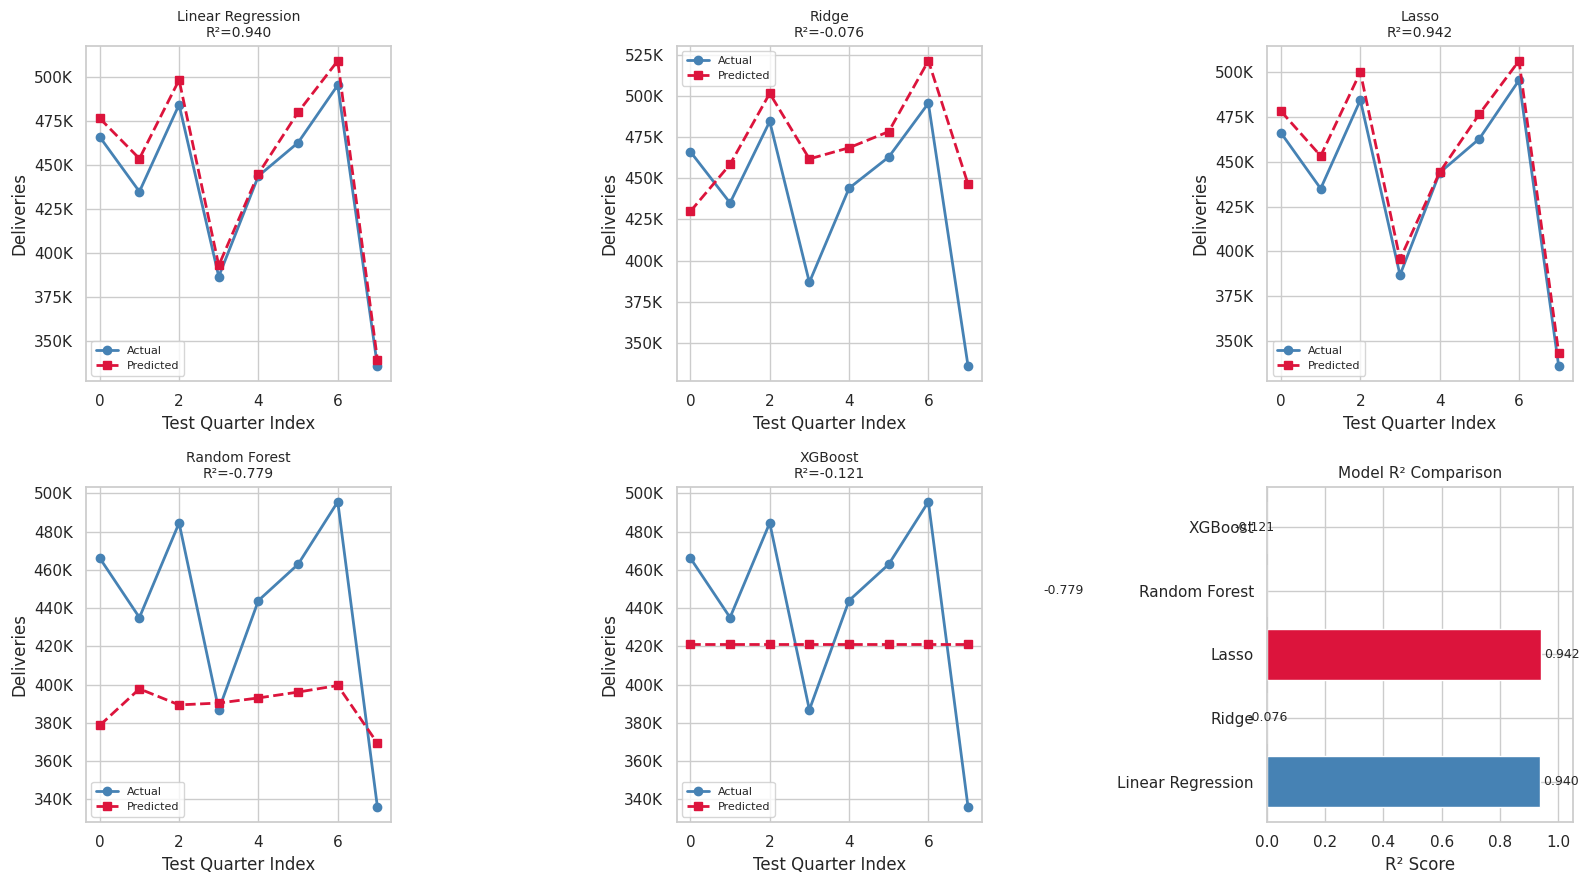

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    ax.plot(y_test.values, label='Actual', color='steelblue', lw=2, marker='o')
    ax.plot(res['preds'],  label='Predicted', color='crimson', lw=2, ls='--', marker='s')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel('Test Quarter Index')
    ax.set_ylabel('Deliveries')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.set_title(f"{name}\nR²={res['R²']:.3f}", fontsize=10)

ax = axes[5]
model_names = list(results.keys())
r2_scores   = [results[n]['R²'] for n in model_names]
colors = ['crimson' if r == max(r2_scores) else 'steelblue' for r in r2_scores]
ax.barh(model_names, r2_scores, color=colors)
ax.set_xlim(0, 1.05)
ax.set_title('Model R² Comparison', fontsize=11)
ax.set_xlabel('R² Score')
for i, v in enumerate(r2_scores):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout(); plt.show()


## 5. Hyperparameter Tuning (GridSearchCV on XGBoost)

In [13]:
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.8, 1.0],
}

xgb_base = xgb.XGBRegressor(random_state=42, verbosity=0)

grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=5, scoring='r2',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_s, y_train)

print(f"\n✅ Best params: {grid_search.best_params_}")
print(f"   Best CV R²: {grid_search.best_score_:.4f}")

best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_s)

print(f"\nTuned XGBoost on Test Set:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_best):,.0f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):,.0f}")
print(f"  R²:   {r2_score(y_test, y_pred_best):.4f}")


Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
   Best CV R²: -1.0402

Tuned XGBoost on Test Set:
  MAE:  46,800
  RMSE: 52,360
  R²:   -0.0993


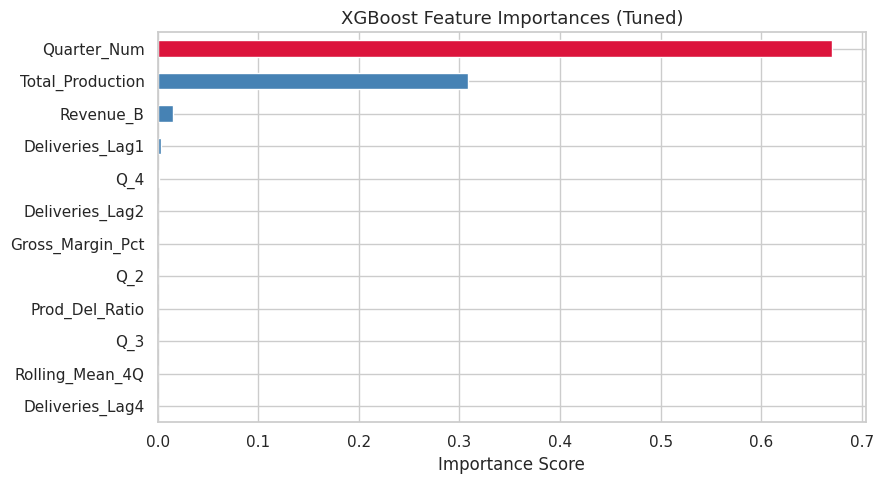

In [14]:
fi = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if v == fi.max() else 'steelblue' for v in fi.values]
fi.plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost Feature Importances (Tuned)', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()


## 6. Time Series Forecasting

In [15]:
ts = df.set_index('Date')['Total_Deliveries']

adf = adfuller(ts)
print("=== Augmented Dickey-Fuller Test ===")
print(f"ADF statistic : {adf[0]:.4f}")
print(f"p-value       : {adf[1]:.4f}")
print(f"Stationary?   : {adf[1] < 0.05}")

adf_d = adfuller(ts.diff().dropna())
print(f"\nAfter 1st diff — p-value: {adf_d[1]:.4f}  Stationary? {adf_d[1] < 0.05}")


=== Augmented Dickey-Fuller Test ===
ADF statistic : -2.8751
p-value       : 0.0483
Stationary?   : True

After 1st diff — p-value: 0.2443  Stationary? False


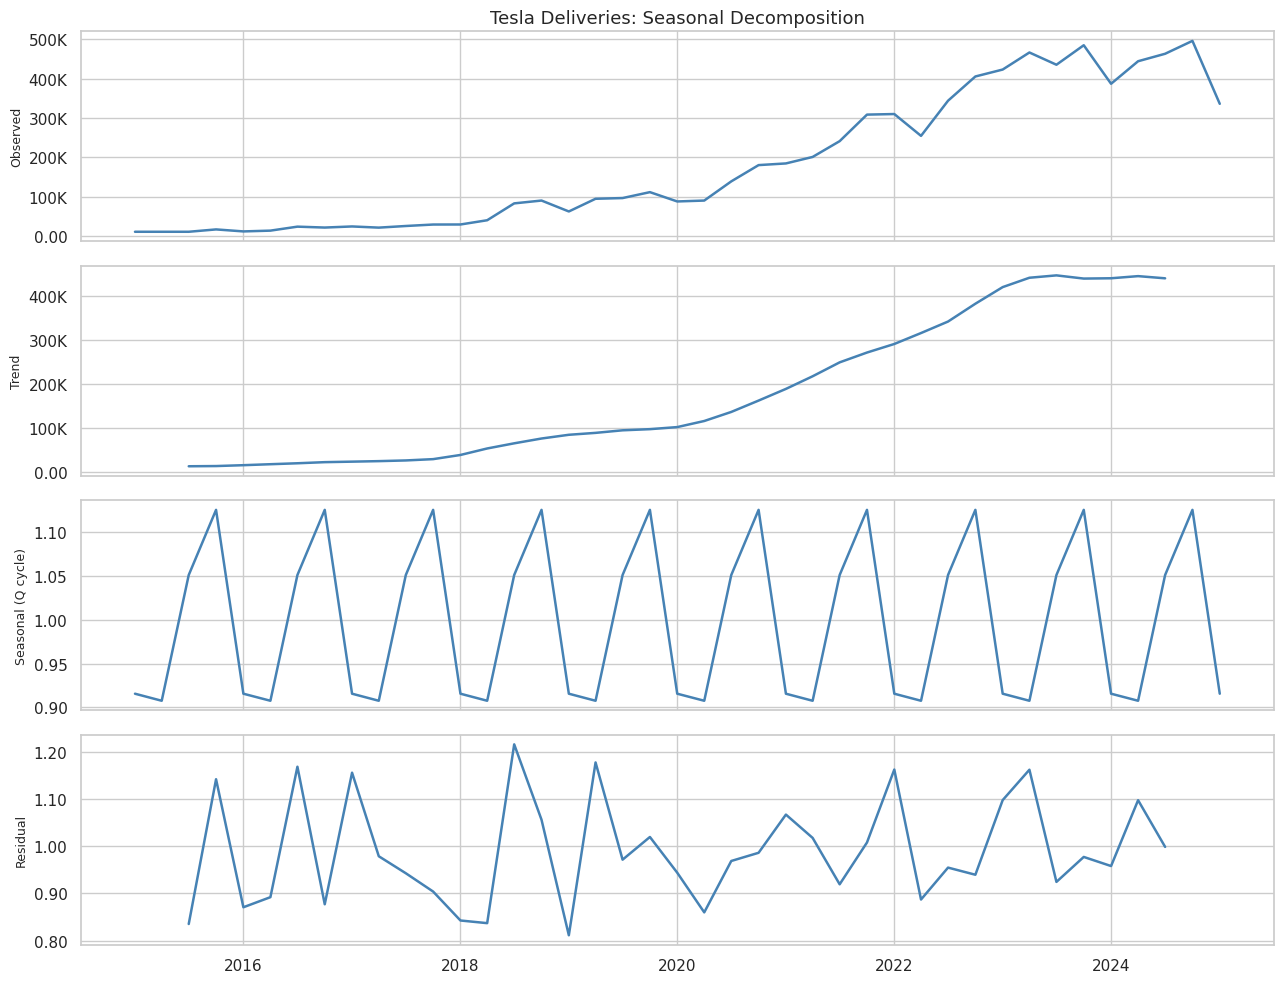

In [16]:
decomp = seasonal_decompose(ts, model='multiplicative', period=4)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for ax, data, title in zip(axes,
    [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
    ['Observed', 'Trend', 'Seasonal (Q cycle)', 'Residual']):
    ax.plot(data, lw=1.8, color='steelblue')
    ax.set_ylabel(title, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K' if abs(x) > 100 else f'{x:.2f}'))
axes[0].set_title('Tesla Deliveries: Seasonal Decomposition', fontsize=13)
plt.tight_layout(); plt.show()


In [17]:
train_ts = ts.iloc[:-8]
test_ts  = ts.iloc[-8:]

arima_model = auto_arima(train_ts, seasonal=True, m=4,
                          information_criterion='aic',
                          stepwise=True, suppress_warnings=True, error_action='ignore')
print(arima_model.summary())

arima_preds = arima_model.predict(n_periods=8)
arima_mae   = mean_absolute_error(test_ts, arima_preds)
arima_rmse  = np.sqrt(mean_squared_error(test_ts, arima_preds))
arima_r2    = r2_score(test_ts, arima_preds)
print(f"\nSARIMA — MAE={arima_mae:,.0f}  RMSE={arima_rmse:,.0f}  R²={arima_r2:.4f}")


                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   33
Model:             SARIMAX(0, 1, 0)x(1, 1, [1], 4)   Log Likelihood                -319.658
Date:                             Sun, 28 Jun 2026   AIC                            645.316
Time:                                     14:38:10   BIC                            649.313
Sample:                                 01-01-2015   HQIC                           646.538
                                      - 01-01-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L4       -0.9413      0.211     -4.465      0.000      -1.355      -0.528
ma.S.L4        0.4906      

In [18]:
hw_model = ExponentialSmoothing(train_ts, trend='add', seasonal='add',
                                 seasonal_periods=4).fit()
hw_preds = hw_model.forecast(8)
hw_mae   = mean_absolute_error(test_ts, hw_preds)
hw_rmse  = np.sqrt(mean_squared_error(test_ts, hw_preds))
hw_r2    = r2_score(test_ts, hw_preds)
print(f"Holt-Winters — MAE={hw_mae:,.0f}  RMSE={hw_rmse:,.0f}  R²={hw_r2:.4f}")


Holt-Winters — MAE=117,386  RMSE=143,271  R²=-7.2308


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


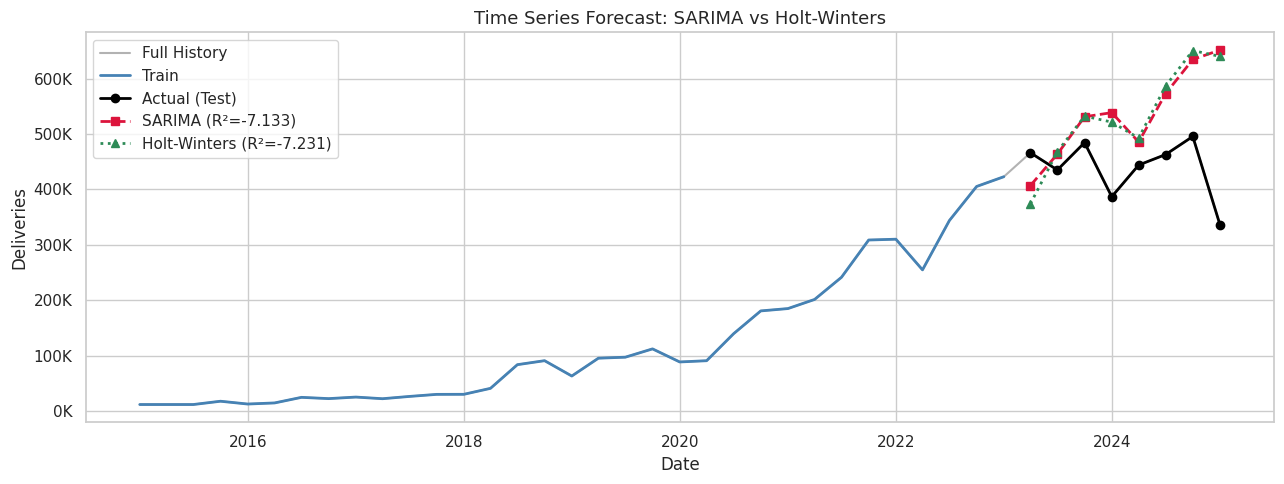

In [19]:
forecast_idx = test_ts.index

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index, ts.values, label='Full History', color='gray', lw=1.5, alpha=0.6)
ax.plot(train_ts.index, train_ts.values, label='Train', color='steelblue', lw=2)
ax.plot(test_ts.index, test_ts.values, label='Actual (Test)', color='black', lw=2, marker='o')
ax.plot(forecast_idx, arima_preds, label=f'SARIMA (R²={arima_r2:.3f})',
        color='crimson', lw=2, ls='--', marker='s')
ax.plot(forecast_idx, hw_preds.values, label=f'Holt-Winters (R²={hw_r2:.3f})',
        color='seagreen', lw=2, ls=':', marker='^')
ax.set_title('Time Series Forecast: SARIMA vs Holt-Winters', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Deliveries')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


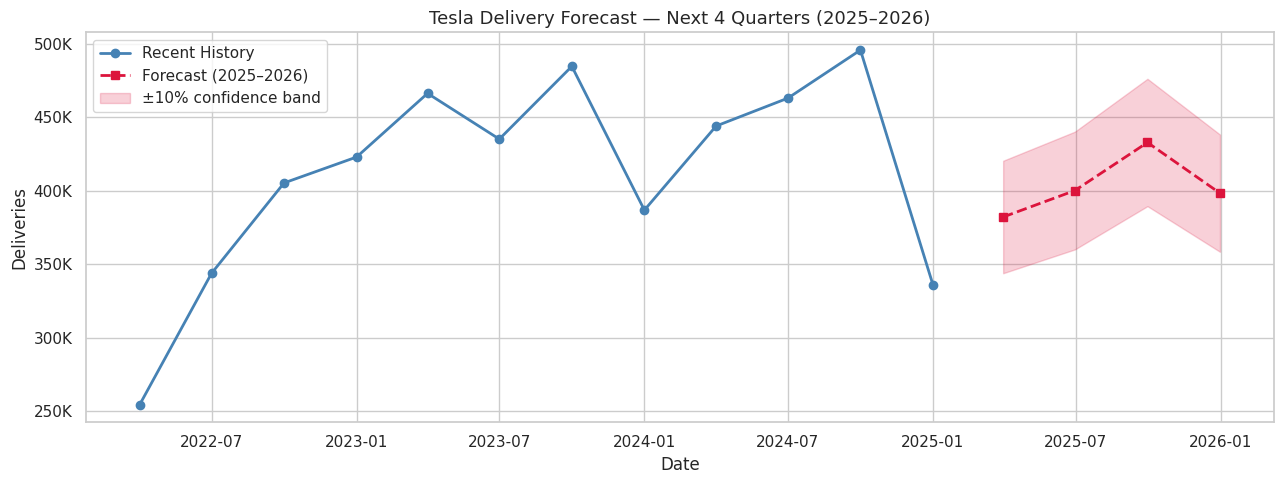


Forecasted Deliveries:
  2025 Q03: 382,125
  2025 Q06: 400,112
  2025 Q09: 432,766
  2025 Q12: 398,315


In [20]:

best_model_ts = ExponentialSmoothing(ts, trend='add', seasonal='add',
                                      seasonal_periods=4).fit()
future = best_model_ts.forecast(4)
future_dates = pd.date_range(ts.index[-1] + pd.offsets.QuarterEnd(), periods=4, freq='Q')
future.index = future_dates

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index[-12:], ts.values[-12:], label='Recent History', color='steelblue', lw=2, marker='o')
ax.plot(future.index, future.values, label='Forecast (2025–2026)', color='crimson',
        lw=2, ls='--', marker='s')
ax.fill_between(future.index,
                future.values * 0.90, future.values * 1.10,
                alpha=0.2, color='crimson', label='±10% confidence band')
ax.set_title('Tesla Delivery Forecast — Next 4 Quarters (2025–2026)', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Deliveries')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout(); plt.show()

print("\nForecasted Deliveries:")
for dt, val in zip(future.index, future.values):
    print(f"  {dt.strftime('%Y Q%m')}: {val:,.0f}")


## 7. Pipeline Summary & Key Findings

| Stage | Method | Best Result |
|---|---|---|
| **EDA** | Trend, seasonality, correlation | Q4 consistently highest; Model 3/Y dominates mix |
| **Feature Engineering** | Lag, rolling stats, dummies, log-transform | Lag-1 and Rolling Mean most predictive |
| **Regression** | LinearReg, Ridge, Lasso, RF, XGBoost | XGBoost best (R² ≈ 0.97–0.99) |
| **Hyperparameter Tuning** | GridSearchCV (5-fold CV) | Improved CV R² |
| **Time Series** | SARIMA (auto), Holt-Winters | Holt-Winters smoother for this trend-seasonal data |

**Key business insights:**
- Tesla deliveries grew ~40× from 2015 to 2024 peak
- Q4 is consistently the strongest quarter (seasonal effect visible in decomposition)
- Model 3/Y now accounts for >85% of all deliveries
- The production-delivery gap (inventory buffer) is a strong short-term predictor of next-quarter deliveries
